# Configure environment

In [1]:
import random
import time
import os
import datetime
import itertools
import math
import sys
from random import randint
import shutil
import gc

In [2]:
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

In [3]:
if IN_COLAB:
  COLAB_BASE_DIR = "/content/gdrive/MyDrive/Universidad/VIU/TFM/notebooks/"
  from google.colab import drive
  drive.mount('/content/gdrive/')
  sys.path.append(os.path.join(COLAB_BASE_DIR, 'ConvLSTM'))
  sys.path.append(os.path.join(COLAB_BASE_DIR, 'common'))

In [4]:
if IN_COLAB:
  if not os.path.exists("/data/masked_clouds.hdf5"):
    %mkdir -p /data
    shutil.copyfile(os.path.join(COLAB_BASE_DIR, "common/masked_clouds.hdf5"), "/data/masked_clouds.hdf5")

In [5]:
#%%capture
#%pip install torch torchvision torchmetrics transformers h5py xarray matplotlib netcdf4 "tensorflow<=2.15.1" opencv-python
%pip install torch torchvision torchmetrics transformers h5py xarray matplotlib netcdf4 tensorflow opencv-python scipy

Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip freeze

absl-py==2.3.0
asttokens==3.0.0
astunparse==1.6.3
cachetools==5.5.2
certifi==2025.6.15
cftime==1.6.4.post1
charset-normalizer==3.4.2
comm==0.2.2
contourpy==1.3.2
cycler==0.12.1
debugpy==1.8.14
decorator==5.2.1
exceptiongroup==1.3.0
executing==2.2.0
filelock==3.18.0
flatbuffers==25.2.10
fonttools==4.58.4
fsspec==2025.5.1
gast==0.6.0
google-auth==2.40.3
google-auth-oauthlib==1.2.2
google-pasta==0.2.0
grpcio==1.73.1
h5netcdf==1.6.3
h5py==3.14.0
hf-xet==1.2.0
huggingface-hub==0.36.0
idna==3.10
ipykernel==6.29.5
ipython==8.37.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.1
jupyter_client==8.6.3
jupyter_core==5.8.1
keras==2.15.0
kiwisolver==1.4.8
libclang==18.1.1
lightning-utilities==0.14.3
Markdown==3.8.2
MarkupSafe==3.0.2
matplotlib==3.10.3
matplotlib-inline==0.1.7
ml-dtypes==0.3.2
mpmath==1.3.0
nest-asyncio==1.6.0
netCDF4==1.7.2
networkx==3.4.2
numpy==1.26.4
nvidia-cublas-cu12==12.1.3.1
nvidia-cuda-cupti-cu12==12.1.105
nvidia-cuda-nvrtc-cu12==12.1.105
nvidia-cuda-runtime-cu12==12.1.105
nvidia-

In [7]:
import torch
import torchmetrics
import torchmetrics.segmentation
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.v2 as v2
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.utils.data as data
from torch.utils.data import DataLoader
import numpy as np
import h5py
import PIL.Image
from IPython.core import display as idisplay
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import tensorflow as tf
import cv2
from scipy.stats import sem, ttest_rel

import ConvLSTMmodels
if not IN_COLAB:
  sys.path.append('../common')
import common

/home/javgat/Repos/SkyMaskConvLSTM/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-16 15:35:03.679074: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-16 15:35:03.679098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-16 15:35:03.680071: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-16 15:35:03.686515: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

In [8]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [9]:
if not IN_COLAB:
  common.set_memory_limit_if_not_limit(1.5)

In [10]:
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2025-12-16 15:35:05.461922: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


# Load data

In [11]:
eval_filename = "maskconvlstm_best_eval.hdf5"

In [12]:
drive_proc_mclstm_path = None
if IN_COLAB:
  drive_proc_mclstm_path = os.path.join(COLAB_BASE_DIR, f'common/{eval_filename}')
  if not os.path.exists("/data/mask_black_skygptdata.png"):
    !gdown 1OEqxhm4NrK1NDsQaBxuG22YY3K92SduH
    %mkdir -p /data
    %mv /content/*.png /data/

In [13]:
cwd = os.getcwd()
model_name_seg = "MaskedConvLSTM_best"
pardir = os.path.dirname(os.path.dirname(cwd))
data_folder = os.path.join(pardir,'data')
mask_path = os.path.join(data_folder,'mask_black_skygptdata.png')
data_path_masked = os.path.join(data_folder, 'masked_clouds.hdf5')
data_path_nomask = os.path.join(data_folder, 'video_prediction_dataset.hdf5')
output_path_seg = os.path.join(cwd, "save", f"{model_name_seg}.torch")
proc_mclstm_path = os.path.join(data_folder, eval_filename)
if IN_COLAB:
  output_path_seg = os.path.join(COLAB_BASE_DIR, "ConvLSTM", f"{model_name_seg}.torch")

## Load models

In [14]:
def load_segconvlstm(path: str, device):
  N_VALUES_CLOUD_MASK = 5
  hidden_dims = [128, 128, 64]
  kernel_size = (3, 3)
  n_layers = 3
  clstm = ConvLSTMmodels.SegmentedConvLSTMNet(hidden_dims, kernel_size, n_layers, device, n_channels=N_VALUES_CLOUD_MASK, batch_normalization=False)
  clstm.load_state_dict(torch.load(path, map_location=device))
  clstm.to(device)
  return clstm

In [15]:
seg_clstm = load_segconvlstm(output_path_seg, device)

/tmp/ipykernel_3812692/3515072466.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clstm.load_state_dict(torch.load(path, map_location=device))


## Load datasets

In [16]:
with h5py.File(data_path_masked, 'r') as fds:
    group_names = list(fds.keys())
    print(group_names)
    fds.close()

dss_masked = {}
for gname in group_names:
    dss_masked[gname] = xr.open_dataset(data_path_masked, engine='h5netcdf', group=gname, phony_dims='sort')

['test', 'trainval']


## Prepare dataloaders

In [17]:
bs = 24
transform = transforms.Compose([
    transforms.Lambda(lambda x: np.unpackbits(x, axis=1)),
    torch.from_numpy,
    transforms.Lambda(lambda x: torch.permute(x, (2, 0, 1)).float()),
])
test_dataset_masked = common.VideoDataset(dss_masked['test']['images_log'], dss_masked['test']['images_pred'], transform=transform, stack_videos=False, device=device)
test_loader_masked = DataLoader(test_dataset_masked, batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)

print(f"Number of videos: {len(test_dataset_masked.videos)}.")
print(f"Number of video batches: {len(test_loader_masked)}")
print(f"Size of video batches: {bs}.")


Number of videos: 4467.
Number of video batches: 187
Size of video batches: 24.


In [18]:
mask_png = np.array(PIL.Image.open(mask_path).resize((64, 64)).getdata())
# Mask for size 64
print(mask_png.shape)
mask_to_black = (mask_png[:,3] > 127)
not_mask_to_black = (mask_png[:,3] <= 127)
print(mask_to_black.sum()) # alpha = 1 = black visible
print(not_mask_to_black.sum())
print(not_mask_to_black.sum()+mask_to_black.sum())
mask_to_black = mask_to_black.reshape((64, 64))
empty_mask = np.ones((64, 64, 3))
mask_to_black = np.where(np.expand_dims(mask_to_black, 2), empty_mask, empty_mask*0)

(4096, 4)
1418
2678
4096


# Process data

In [19]:
N_VALUES_CLOUD_MASK = 5

## Data visualizer

In [20]:
cmap = mcolors.ListedColormap(['black', 'cyan', 'yellow', 'white', 'blue'], 'CloudSegmenter')
def show_mask(img):
    labels_again = torch.argmax(img, dim=1).cpu()
    f = plt.figure(figsize=(9, 9), layout='tight')
    ncols = len(img)//4 if len(img) % 4 == 0 else len(img)//4 + 1
    axarr = f.subplots(4,4)
    for i in range(16):
      axarr[i//4][i%4].set_axis_off()
    for i in range(len(img)):
        axarr[i//4][i%4].imshow(labels_again[i], cmap=cmap, vmin=0, vmax=5)
    plt.show()

In [21]:
def show_nomask(img):
    img = img.permute(0, 2, 3, 1).cpu().numpy()[:,:,:,::-1]
    f = plt.figure(figsize=(9, 9), layout='tight')
    axarr = f.subplots(4,4)
    for i in range(16):
      axarr[i//4][i%4].set_axis_off()
    for i in range(len(img)):
        axarr[i//4][i%4].imshow(img[i])
    plt.show()

## Test data loading and visualization

0
torch.Size([24, 16, 5, 64, 64])


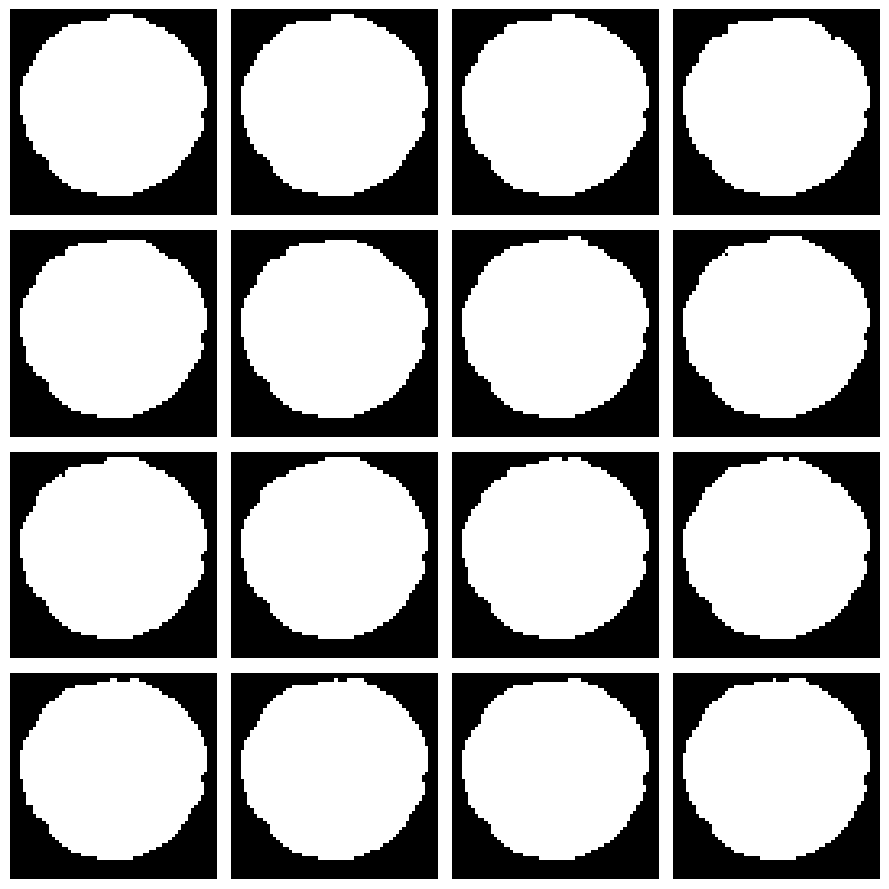

RuntimeError: [enforce fail at alloc_cpu.cpp:117] err == 0. DefaultCPUAllocator: can't allocate memory: you tried to allocate 201326592 bytes. Error code 12 (Cannot allocate memory)

In [22]:
with torch.no_grad():
  for idx, (videos, targets) in enumerate(test_loader_masked):
    print(idx)
    print(videos.shape)
    show_mask(videos[1].data.cpu())
    pred = seg_clstm(videos, 15)
    print(pred.shape)
    show_mask(pred[1].data.cpu())
    break

In [ ]:
print(pred[1].min())
print(pred[1].max())

## Process data and generate comparison files
(if necessary)

In [29]:
def process_and_store(path: str, test_loader_masked, bs, seg_clstm):
  with h5py.File(path, 'w') as f:
    test_group = f.create_group('test')
    lendataset = len(test_dataset_masked)
    num_log_frame = 16
    num_pred_frame = 15
    img_side_len = 64
    maskst_log_dset = test_group.create_dataset('masks_log', shape=(lendataset, num_log_frame, img_side_len, img_side_len/8, N_VALUES_CLOUD_MASK), dtype=np.uint8)
    maskst_targ_dset = test_group.create_dataset('masks_targ', shape=(lendataset, num_pred_frame, img_side_len, img_side_len/8, N_VALUES_CLOUD_MASK), dtype=np.uint8)
    maskst_pred_seg_dset = test_group.create_dataset('masks_pred_seg', shape=(lendataset, num_pred_frame, img_side_len, img_side_len/8, N_VALUES_CLOUD_MASK), dtype=np.uint8)
    with torch.no_grad():
      for idx, (videos, targets) in enumerate(test_loader_masked):
        videos = videos.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        mini = idx*bs
        maxi = (idx+1)*bs
        pred = seg_clstm(videos, 15, apply_softmax=True)
        pred = torch.argmax(pred, dim=2)
        pred = torch.from_numpy(np.eye(N_VALUES_CLOUD_MASK)[pred.cpu()]).bool()
        pred = pred.permute((0, 1, 4, 2, 3))
        videos = videos.permute((0, 1, 3, 4, 2))
        targets = targets.permute((0, 1, 3, 4, 2))
        pred = pred.permute((0, 1, 3, 4, 2))
        maskst_log_dset[mini:maxi] = np.packbits(videos.bool().cpu().numpy(), axis=3)
        maskst_targ_dset[mini:maxi] = np.packbits(targets.bool().cpu().numpy(), axis=3)
        maskst_pred_seg_dset[mini:maxi] = np.packbits(pred.bool().cpu().numpy(), axis=3)
        if idx%10==0:
          print(f"{idx}/{len(test_loader_masked)}")

In [30]:
if IN_COLAB:
  if os.path.exists(drive_proc_mclstm_path):
    print('Masked clouds file already exists. Copying...')
    shutil.copyfile(drive_proc_mclstm_path, proc_mclstm_path)
  else:
    print('Masked clouds doesn\'t exist. Processing...')
    process_and_store(proc_mclstm_path, test_loader_masked, bs, seg_clstm)
    print('Saving in drive...')
    shutil.copyfile(proc_mclstm_path, drive_proc_mclstm_path)

In [31]:
if not os.path.exists(proc_mclstm_path):
  print('proc_mclstm_path file not available. Download it.')

with h5py.File(proc_mclstm_path, 'r') as fds:
    group_names = list(fds.keys())
    print(group_names)
    fds.close()

dsm = {}
for gname in group_names:
    dsm[gname] = xr.open_dataset(proc_mclstm_path, group=gname, engine="h5netcdf", phony_dims='sort')

['test']


## Load processed data

In [32]:
bs = 24

In [33]:
transform = transforms.Compose([
    transforms.Lambda(lambda x: np.unpackbits(x, axis=1)),
    torch.from_numpy,
    transforms.Lambda(lambda x: torch.permute(x, (2, 0, 1)).float()),
])
btest_dataset_mask = common.VideoDataset(dsm['test']['masks_targ'], dsm['test']['masks_pred_seg'], transform=transform, stack_videos=False, device=device)
btest_loader_mask = DataLoader(btest_dataset_mask, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

In [34]:
for idx, (mtarg, mseg) in enumerate(btest_loader_mask):
  print(idx)
  print(mtarg.shape)
  print(mseg.shape)
  break

0
torch.Size([24, 15, 5, 64, 64])
torch.Size([24, 15, 5, 64, 64])


0


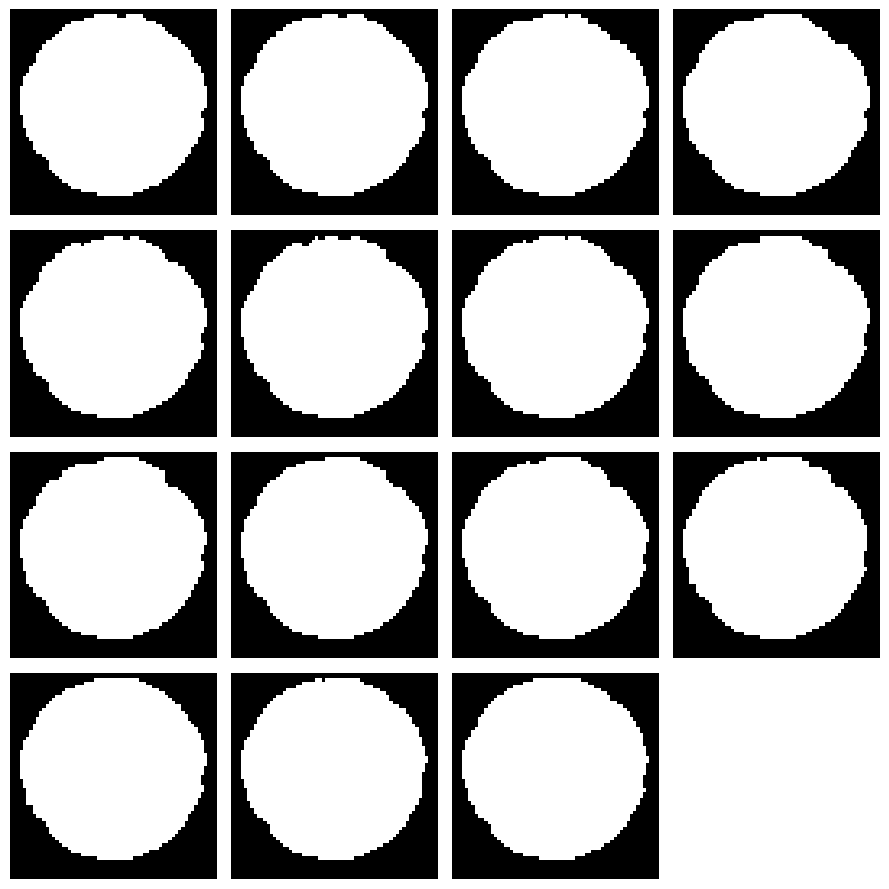

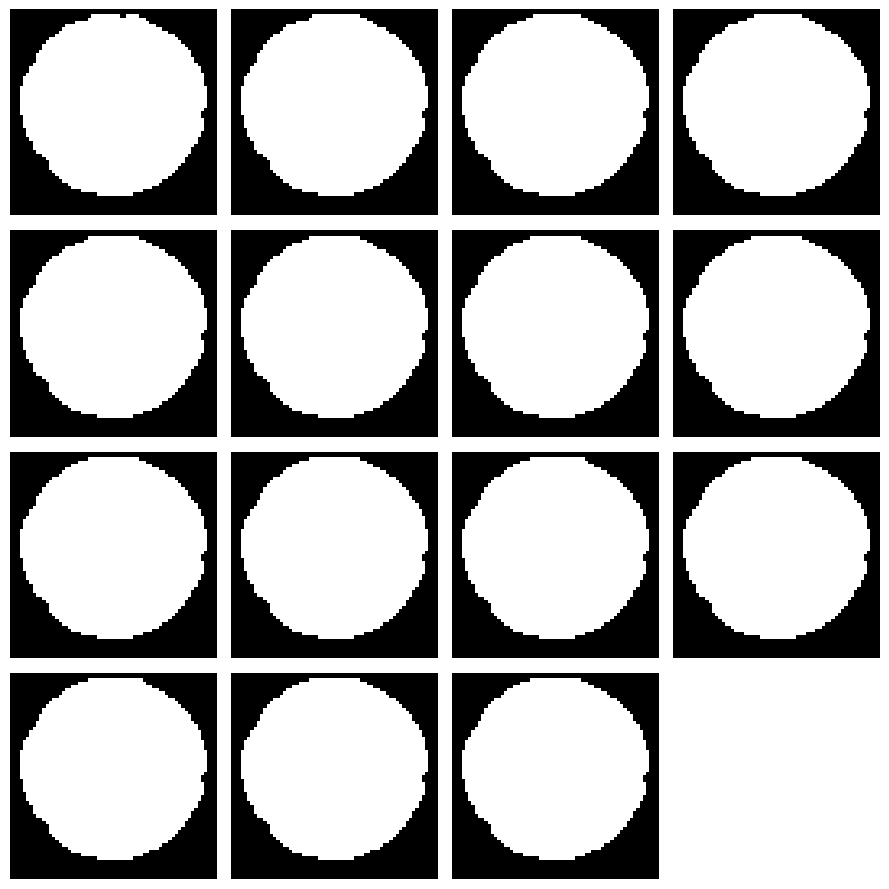

In [35]:
for idx, (mtarg, mseg) in enumerate(btest_loader_mask):
  print(idx)
  showid = 3
  show_mask(mtarg[showid])
  show_mask(mseg[showid])
  break

In [36]:
def _show_vid_mask_data(vid_data):
  vid_data = vid_data[::2].flip(dims=(1,))
  voutput = torch.zeros(len(vid_data), 3, vid_data.size(-2), vid_data.size(-1), dtype=torch.float).to(device)
  for img_idx, img in enumerate(vid_data):
    img = img.unsqueeze(0)
    class_to_color = [torch.tensor([0, 0, 255]), torch.tensor([255, 255, 255]), torch.tensor([255, 255, 0]), torch.tensor([0, 255, 255]), torch.tensor([0, 0, 0])]
    output = torch.zeros(1, 3, vid_data.size(-2), vid_data.size(-1), dtype=torch.float).to(device)
    for class_idx, color in enumerate(class_to_color):
      mask = img[:,class_idx,:,:] == torch.max(img, dim=1)[0]
      mask = mask.unsqueeze(1) # should have shape 1, 1, 100, 100
      curr_color = color.reshape(1, 3, 1, 1).to(device)
      segment = mask*curr_color # should have shape 1, 3, 100, 100
      output += segment
    voutput[img_idx] = output.squeeze(0)
  torchvision.utils.save_image(voutput, 'save/real_image.png')
  display(idisplay.Image('save/real_image.png'))


def _show_vid_data(vid_data):
  vid_data = vid_data[::2].flip(dims=(1,))
  torchvision.utils.save_image(vid_data, 'save/real_image.png')
  display(idisplay.Image('save/real_image.png'))

## Full data processing

In [ ]:
mse = nn.MSELoss()
_jaca = torchmetrics.JaccardIndex(task="multiclass", num_classes=5).to(device)
def jac(x, y):
  if len(x.shape) == 5:
    x = x.flatten(0, 1)
    y = y.flatten(0, 1)
  return _jaca(torch.argmax(x, axis=1), torch.argmax(y, axis=1))
try:
  _dice = torchmetrics.Dice().to(device)
except AttributeError:
  _dice = torchmetrics.segmentation.DiceScore(
      num_classes=5,
      input_format="index",
      average="micro",
      aggregation_level="global",
  ).to(device)
dice = lambda x, y: _dice(
    torch.argmax(x, axis=len(x.shape)-3),
    torch.argmax(y, axis=len(y.shape)-3)
)
_cce = nn.CrossEntropyLoss()
def cce(x, y):
  if len(x.shape) == 5:
    x = x.permute(0, 2, 1, 3, 4)
    y = y.permute(0, 2, 1, 3, 4)
  return _cce(x, y)
loss_functions = [mse, cce, jac, dice]

losses_tsteps_seg = [[[] for _ in range(15)] for _ in range(len(loss_functions))]
losses_seg = [0 for _ in range(len(loss_functions))]


for idx, (mtarg, mseg) in enumerate(btest_loader_mask):
  mtarg = mtarg.to(device, non_blocking=True)
  mseg = mseg.to(device, non_blocking=True)
  with torch.no_grad():
    for i in range(15):
      for l, lossf in enumerate(loss_functions):
        lossp = lossf(mseg[:,i,:,:,:], mtarg[:,i,:,:,:])
        losses_tsteps_seg[l][i].append(lossp.item())
    for l, lossf in enumerate(loss_functions):
      lossp = lossf(mseg, mtarg)
      losses_seg[l] += lossp.item()
    lossp = None
    if idx % 10 == 0:
        to_print = (
            f"B[{idx+1}/{len(btest_loader_mask)}]"
            f" AccLoss SEG: {np.mean(losses_seg)/bs:.4g} "
        )
        print(to_print)

In [ ]:
n_vidba = 187
losses_seg = np.array(losses_seg)/n_vidba

In [ ]:
losses_tsteps_seg_path = os.path.join(data_folder, 'tsteps_seg.npy')

In [ ]:
np.save(losses_tsteps_seg_path, np.array(losses_tsteps_seg))

In [ ]:
means_seg = np.mean(losses_tsteps_seg, axis=2)
ci95_seg = 1.96 * sem(losses_tsteps_seg, axis=2)
std_seg = np.std(losses_tsteps_seg, axis=2)

In [ ]:
print(repr(means_seg))
print(repr(losses_seg))
print(repr(std_seg))
print(repr(ci95_seg))

In [ ]:
means_seg = np.zeros((len(loss_functions), 15))
stds_seg = np.zeros((len(loss_functions), 15))

for l in range(len(loss_functions)):
    for i in range(15):
        means_seg[l, i] = np.mean(losses_tsteps_seg[l][i])
        stds_seg[l, i] = np.std(losses_tsteps_seg[l][i])

In [ ]:
print(losses_tsteps_seg)
print(losses_seg)

In [ ]:
losses_names = ['MSE', 'Cross Entropy', 'Jaccard Index', 'Dice Coefficient']

In [ ]:
means_noseg = [[0.01870207, 0.02406489, 0.02789866, 0.03099857, 0.03347814,
        0.03552296, 0.03728211, 0.03871344, 0.04001388, 0.04119037,
        0.04238339, 0.04350626, 0.04451778, 0.0455299 , 0.04643907],
       [0.95158766, 0.96499472, 0.97457915, 0.98232892, 0.98852783,
        0.9936399 , 0.99803776, 1.00161609, 1.00486721, 1.00780843,
        1.01079096, 1.01359815, 1.01612694, 1.01865724, 1.02093017],
       [0.71730926, 0.68331353, 0.66281711, 0.64709313, 0.63529405,
        0.6357139 , 0.6280362 , 0.62292346, 0.61932218, 0.61323612,
        0.60802194, 0.60251451, 0.59863618, 0.59571261, 0.59398487],
       [0.95324483, 0.93983777, 0.93025334, 0.92250357, 0.91630466,
        0.91119259, 0.90679473, 0.9032164 , 0.89996529, 0.89702406,
        0.89404153, 0.89123435, 0.88870556, 0.88617526, 0.88390233]]
losses_noseg = [0.03668277, 0.99653945, 0.58664872, 0.90829309]
std_noseg = [[0.01715703, 0.0225521 , 0.02648864, 0.02976437, 0.0324006 ,
        0.03454966, 0.03634894, 0.03800827, 0.03949447, 0.04079178,
        0.04195408, 0.04304942, 0.04402911, 0.04507531, 0.04603875],
       [0.04289255, 0.05638023, 0.0662216 , 0.07441092, 0.0810015 ,
        0.08637415, 0.09087234, 0.09502067, 0.09873617, 0.10197945,
        0.1048852 , 0.10762354, 0.11007276, 0.11268828, 0.11509687],
       [0.16652   , 0.18226039, 0.18929121, 0.19572545, 0.19817211,
        0.20528554, 0.2099487 , 0.21268779, 0.21487099, 0.21617447,
        0.21725372, 0.21660256, 0.21627535, 0.21769164, 0.21973034],
       [0.04289257, 0.05638024, 0.0662216 , 0.07441093, 0.08100151,
        0.08637415, 0.09087235, 0.09502067, 0.09873617, 0.10197946,
        0.1048852 , 0.10762354, 0.11007277, 0.11268828, 0.11509687]]
ci95_noseg = [[0.00142358, 0.00187122, 0.00219785, 0.00246965, 0.00268839,
        0.0028667 , 0.003016  , 0.00315368, 0.00327699, 0.00338463,
        0.00348107, 0.00357196, 0.00365325, 0.00374005, 0.00381999],
       [0.00355894, 0.00467806, 0.00549463, 0.00617413, 0.00672097,
        0.00716676, 0.00753999, 0.00788419, 0.00819248, 0.00846158,
        0.00870268, 0.00892989, 0.00913311, 0.00935013, 0.00954998],
       [0.01381673, 0.01512277, 0.01570614, 0.01624001, 0.01644302,
        0.01703324, 0.01742016, 0.01764743, 0.01782858, 0.01793673,
        0.01802628, 0.01797225, 0.0179451 , 0.01806262, 0.01823178],
       [0.00355894, 0.00467806, 0.00549463, 0.00617413, 0.00672097,
        0.00716676, 0.00753999, 0.00788419, 0.00819248, 0.00846158,
        0.00870268, 0.00892989, 0.00913311, 0.00935013, 0.00954998]]

In [ ]:
for ms, cs, mns, cns, name in zip(means_seg, ci95_seg, means_noseg, ci95_noseg, losses_names):
  #plt.plot(range(1, 16), lstes, '-o', label='MaskConvLSTM')
  plt.errorbar(range(1, 16), ms, cs, fmt="-o", label="MaskConvLSTM", capsize=3)
  #plt.plot(range(1, 16), lstens, '-o', label='ConvLSTM')
  plt.errorbar(range(1, 16), mns, cns, fmt="-o", label="ConvLSTM", capsize=3)
  plt.xlabel('Time step (min)')
  plt.ylabel(name)
  plt.legend()
  plt.grid()
  plt.show()

In [ ]:
"""p_vals = []

print("Timestep | p-value | significant?")
print("-----------------------------")

for lseg, lnoseg, name in zip(losses_tsteps_seg, losses_tsteps_noseg, losses_names):
    for t in range(15):
        seg = np.array(lseg[t])
        nose = np.array(lnoseg[t])

        # Paired t-test
        stat, p = ttest_rel(seg, nose)
        p_vals.append(p)

        print(f"t+{t+1:2}     | {p:.4e} | {'YES' if p < 0.05 else 'no'}")"""

In [24]:
from sklearn.metrics import confusion_matrix

def compute_avg_conf_matrix(predictions, targets, num_classes=5):
    conf_total = np.zeros((num_classes, num_classes), dtype=np.int64)
    for y_true, y_pred in zip(targets, predictions):
        y_true = torch.argmax(y_true, dim=0)
        y_pred = torch.argmax(y_pred, dim=0)
        cm = confusion_matrix(y_true.flatten(), y_pred.flatten(), labels=list(range(num_classes)))
        conf_total += cm
    return conf_total

In [37]:
confs_tsteps_seg = [np.zeros((5, 5)) for _ in range(15)]
for idx, (mtarg, mseg) in enumerate(btest_loader_mask):
  with torch.no_grad():
    for i in range(15):
      confs_tsteps_seg[i] += compute_avg_conf_matrix(mseg[:,i,:,:,:], mtarg[:,i,:,:,:])
    if idx % 25 == 0:
        to_print = (
            f"B[{idx+1}/{len(btest_loader_mask)}]"
        )
        print(to_print)
        display(confs_tsteps_seg[0])

B[1/187]


array([[37995.,     0.,     0.,   236.,     0.],
       [    0.,     0.,     0.,     0.,     0.],
       [    0.,     0.,     0.,     0.,     0.],
       [  177.,     0.,     0., 59896.,     0.],
       [    0.,     0.,     0.,     0.,     0.]])

B[26/187]


array([[9.679330e+05, 9.300000e+02, 0.000000e+00, 6.646000e+03,
        4.000000e+00],
       [9.570000e+02, 4.053110e+05, 5.390000e+02, 2.814300e+04,
        4.362000e+03],
       [0.000000e+00, 6.060000e+02, 6.982000e+03, 9.600000e+02,
        1.270000e+02],
       [5.083000e+03, 2.126000e+04, 7.690000e+02, 1.072993e+06,
        3.042000e+03],
       [1.000000e+00, 9.739000e+03, 3.250000e+02, 7.720000e+03,
        1.147200e+04]])

B[51/187]


...

array([[4.610341e+06, 2.501000e+03, 0.000000e+00, 2.416800e+04,
        5.800000e+01],
       [2.481000e+03, 1.366290e+06, 1.616000e+03, 1.349910e+05,
        4.026700e+04],
       [0.000000e+00, 1.732000e+03, 2.499500e+04, 2.166000e+03,
        1.239000e+03],
       [2.134900e+04, 9.753600e+04, 1.688000e+03, 5.653631e+06,
        2.778000e+04],
       [4.700000e+01, 5.456000e+04, 1.375000e+03, 4.562100e+04,
        2.698720e+05]])

B[151/187]


array([[5.505025e+06, 2.669000e+03, 0.000000e+00, 2.742800e+04,
        5.800000e+01],
       [2.560000e+03, 1.499536e+06, 1.616000e+03, 1.597810e+05,
        4.088900e+04],
       [0.000000e+00, 1.732000e+03, 2.499500e+04, 2.166000e+03,
        1.239000e+03],
       [2.487100e+04, 1.148960e+05, 1.688000e+03, 7.026798e+06,
        2.857300e+04],
       [5.000000e+01, 5.681000e+04, 1.375000e+03, 4.711100e+04,
        2.720380e+05]])

B[176/187]


array([[6.402156e+06, 2.729000e+03, 0.000000e+00, 3.187000e+04,
        5.900000e+01],
       [2.600000e+03, 1.547779e+06, 1.616000e+03, 1.828280e+05,
        4.240000e+04],
       [0.000000e+00, 1.732000e+03, 2.499500e+04, 2.166000e+03,
        1.239000e+03],
       [2.889200e+04, 1.274890e+05, 1.688000e+03, 8.474208e+06,
        3.224600e+04],
       [5.200000e+01, 6.188300e+04, 1.375000e+03, 5.315200e+04,
        2.763500e+05]])

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_conf_matrix(cm, classes, title, ax, normalize=True):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap='YlGnBu', xticklabels=classes, yticklabels=classes, square=True, cbar=True, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Ground Truth')
    ax.set_title(title)

In [ ]:
class_names = ["Other", "Cloud-free", "Sun", "Cloud", "Thin cloud"]
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
for i, step in enumerate([0, 4, 9, 14]):
    plot_conf_matrix(confs_tsteps_seg[step], class_names, f"MaskConvLSTM t={step+1}", axs[i//2][i%2])
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(6, 5))
plot_conf_matrix(np.sum(confs_tsteps_seg, axis=0), class_names, "MaskConvLSTM", ax)
plt.tight_layout()
plt.show()

In [ ]:
def plot_conf_matrix_precission(cm, classes, title, ax, normalize=True):
    cm = cm.T
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)
    cm = cm.T
    sns.heatmap(cm, annot=True, fmt=".2f", cmap='YlGnBu', xticklabels=classes, yticklabels=classes, square=True, cbar=True, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Ground Truth')
    ax.set_title(title)

In [43]:
class_names = ["Other", "Cloud-free", "Sun", "Cloud", "Thin cloud"]

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
for i, step in enumerate([0, 4, 9, 14]):
    plot_conf_matrix_precission(confs_tsteps_seg[step], class_names, f"MaskConvLSTM t={step+1}", axs[i//2][i%2])
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(6, 5))
plot_conf_matrix_precission(np.sum(confs_tsteps_seg, axis=0), class_names, "MaskConvLSTM", ax)
plt.tight_layout()
plt.show()

In [39]:
def iou_dice_per_class_per_timestep(confs_tsteps_seg, eps=1e-7):
  """
  confs_tsteps_seg: list de length T
      cada elemento: numpy array (C, C), filas=GT, cols=Pred

  devuelve:
      iou_t:   (T, C)
      dice_t:  (T, C)
      support: (T, C)  # nº pix GT por clase
  """
  T = len(confs_tsteps_seg)
  C = confs_tsteps_seg[0].shape[0]

  iou_t = np.zeros((T, C), dtype=np.float64)
  dice_t = np.zeros((T, C), dtype=np.float64)
  support_t = np.zeros((T, C), dtype=np.float64)

  for t, cm in enumerate(confs_tsteps_seg):
    cm = cm.astype(np.float64)

    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    support = cm.sum(axis=1)

    denom_iou = tp + fp + fn
    denom_dice = 2 * tp + fp + fn

    iou_t[t] = np.divide(tp, denom_iou + eps)
    dice_t[t] = np.divide(2 * tp, denom_dice + eps)
    support_t[t] = support

  return iou_t, dice_t, support_t

In [40]:
iou_t, dice_t, support_t = iou_dice_per_class_per_timestep(confs_tsteps_seg)


In [41]:
tsteps_iou_noseg_path = os.path.join(data_folder, 'tsteps_iou_noseg.npy')
tsteps_dice_noseg_path = os.path.join(data_folder, 'tsteps_dice_noseg.npy')
ns_iou_t = np.load(tsteps_iou_noseg_path)
ns_dice_t = np.load(tsteps_dice_noseg_path)

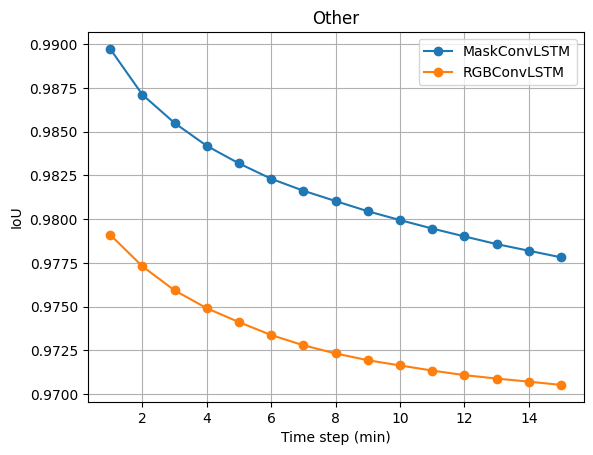

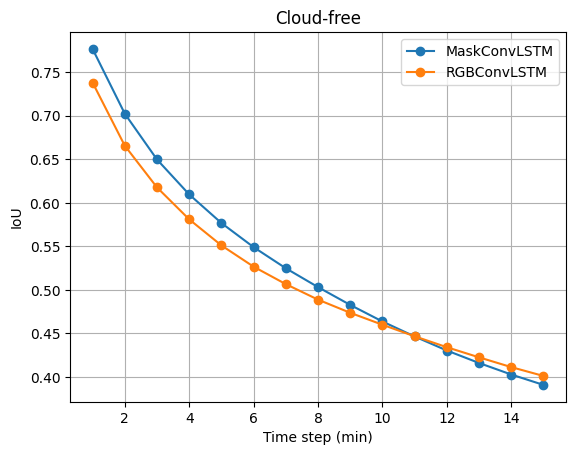

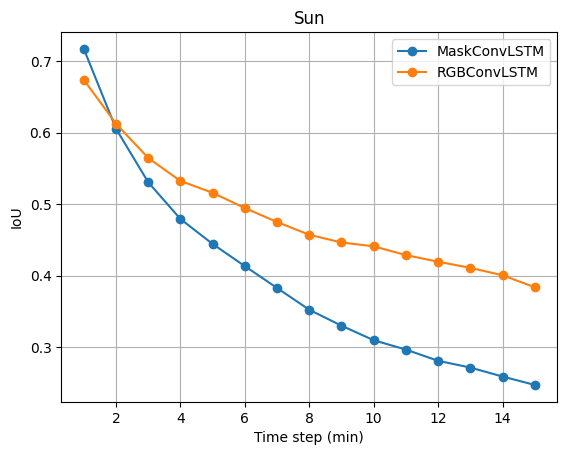

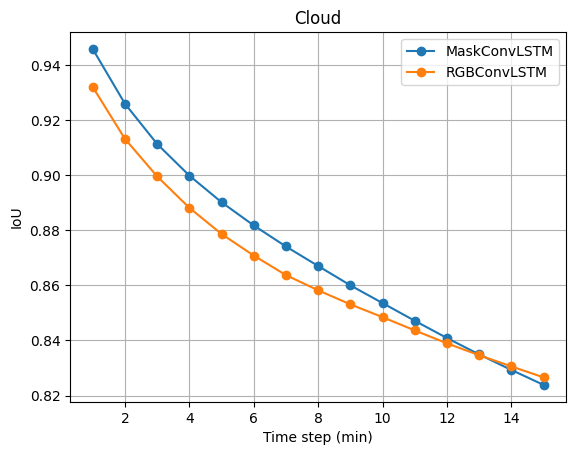

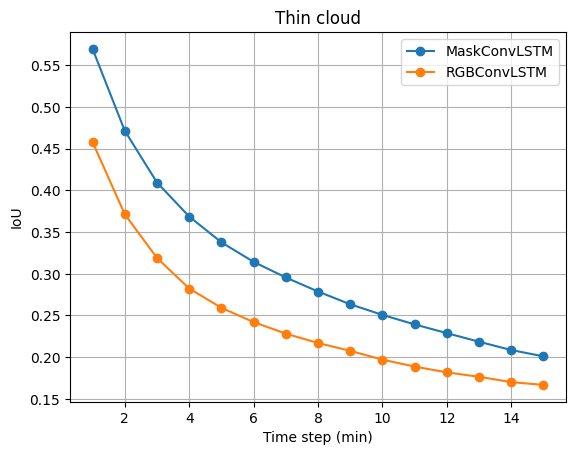

In [45]:
for i, cname in enumerate(class_names):
  segvals = iou_t[:, i]
  nosegvals = ns_iou_t[:, i]
  plt.plot(range(1, 16), segvals, '-o', label='MaskConvLSTM')
  plt.plot(range(1, 16), nosegvals, '-o', label='RGBConvLSTM')
  plt.xlabel('Time step (min)')
  plt.title(cname)
  plt.ylabel("IoU")
  plt.legend()
  plt.grid()
  plt.show()

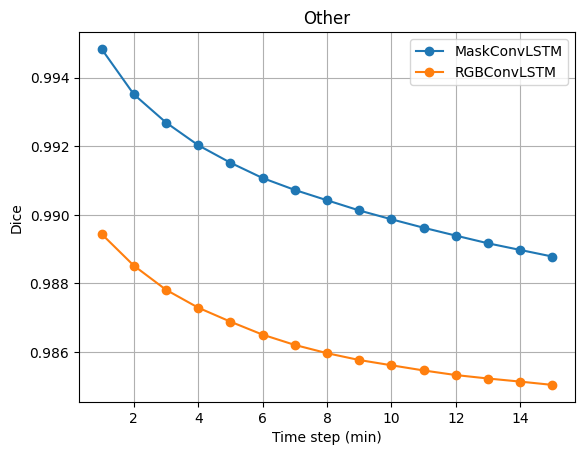

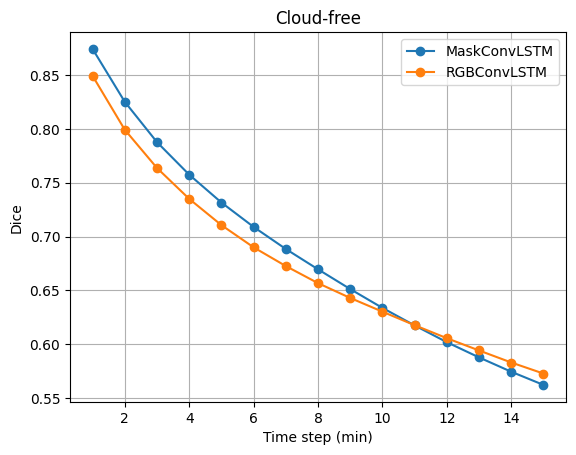

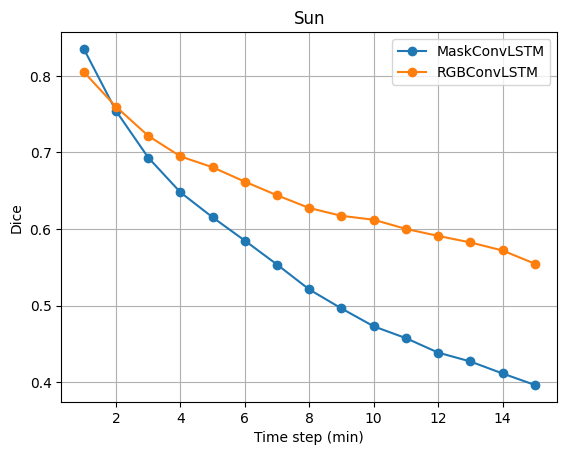

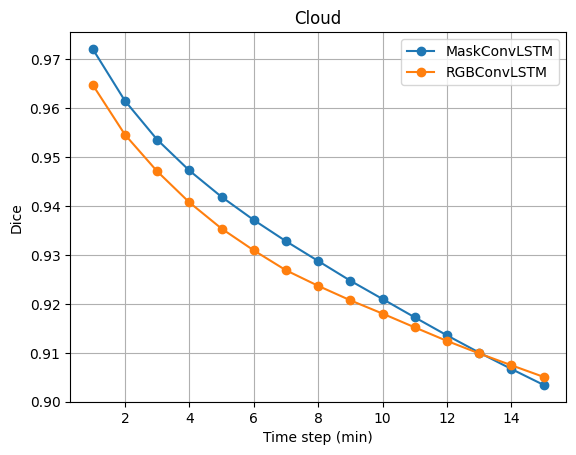

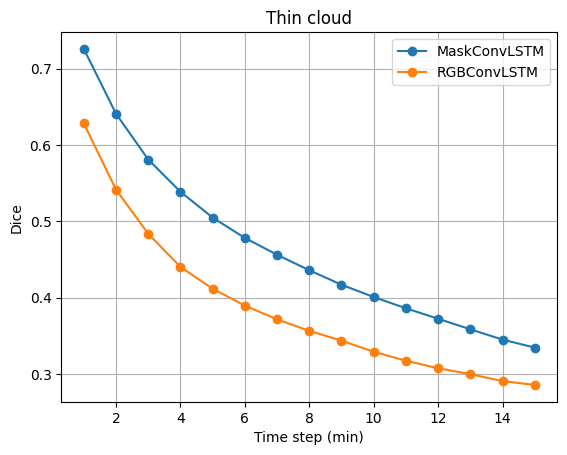

In [46]:
for i, cname in enumerate(class_names):
  segvals = dice_t[:, i]
  nosegvals = ns_dice_t[:, i]
  plt.plot(range(1, 16), segvals, '-o', label='MaskConvLSTM')
  plt.plot(range(1, 16), nosegvals, '-o', label='RGBConvLSTM')
  plt.xlabel('Time step (min)')
  plt.title(cname)
  plt.ylabel("Dice")
  plt.legend()
  plt.grid()
  plt.show()

In [ ]:
amounts = np.array(confs_tsteps_seg).sum(axis=2).sum(axis=0)
print(amounts/amounts.sum())

In [ ]:
def get_diag(cm):
    cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm = np.nan_to_num(cm)
    return np.diag(cm)

seg_diags = np.zeros((15, 5))
for i in range(15):
    seg_diags[i] += get_diag(confs_tsteps_seg[i])
print(class_names)
print(seg_diags)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
scores = seg_diags
tsteps_labels = [f't={i}' for i in range(1,16)]
sns.heatmap(scores, annot=True, fmt=".3f", cmap='YlGnBu', xticklabels=class_names, yticklabels=tsteps_labels, square=True, cbar=True, ax=ax)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel('')
ax.set_ylabel('Time step $t$')
ax.text(0.5, 1.04, 'MaskConvLSTM', ha='center', va='bottom', fontsize='large', fontweight='bold', transform=ax.transAxes)
ax.axvline(5, color='white', linewidth=2)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
for idx, (mtarg, mseg) in enumerate(btest_loader_mask):
  if idx % 10 == 0:
    print(f"{idx}/{len(btest_loader_mask)}")
    show_mask(mtarg[0])
    show_mask(mseg[0])